# Image Classification Model Training
## MobileNetV2 Transfer Learning for Home Service Job Classification

This notebook trains an image classifier using transfer learning with MobileNetV2.
We freeze the pretrained backbone and only train the classifier head on our home service image dataset.

**Architecture**: MobileNetV2 (pretrained on ImageNet) → Frozen backbone → Custom classifier (1280 → 6 classes)

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

IMAGE_DIR = os.path.join(PROJECT_ROOT, 'data', 'images')
MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
FIGURE_DIR = os.path.join(PROJECT_ROOT, 'report', 'figures')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')

Using device: cpu


## 1. Data Loading and Augmentation

We apply aggressive data augmentation to compensate for our small dataset size:
- Random horizontal flip
- Random rotation (up to 20 degrees)
- Color jitter (brightness, contrast, saturation)
- Random resized crop
- Normalization with ImageNet statistics

In [2]:
# Define transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Load full dataset to get class info
full_dataset = datasets.ImageFolder(IMAGE_DIR, transform=train_transform)
class_names = full_dataset.classes
num_classes = len(class_names)

print(f'Classes: {class_names}')
print(f'Number of classes: {num_classes}')
print(f'Total images: {len(full_dataset)}')

# Count per class
from collections import Counter
class_counts = Counter([full_dataset.targets[i] for i in range(len(full_dataset))])
for idx, name in enumerate(class_names):
    print(f'  {name}: {class_counts[idx]}')

Classes: ['electrical', 'general_repair', 'hvac', 'painting', 'plumbing', 'roofing']
Number of classes: 6
Total images: 90
  electrical: 15
  general_repair: 15
  hvac: 15
  painting: 15
  plumbing: 15
  roofing: 15


In [3]:
# Split dataset: 70% train, 15% val, 15% test
total = len(full_dataset)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size], generator=generator
)

# Override transform for val/test
val_dataset.dataset = datasets.ImageFolder(IMAGE_DIR, transform=val_transform)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

Train: 62 | Val: 13 | Test: 15


## 2. Model Architecture

MobileNetV2 with frozen backbone — only the final classifier layer is trainable.

In [4]:
from src.cv_pipeline import build_model

model = build_model(num_classes=num_classes)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,} ({trainable_params/total_params:.1%})')
print(f'Frozen parameters: {frozen_params:,} ({frozen_params/total_params:.1%})')
print(f'\nClassifier head:\n{model.classifier}')

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /Users/othmarcasilla/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


  0%|          | 0.00/13.6M [00:00<?, ?B/s]

  1%|          | 128k/13.6M [00:00<00:11, 1.19MB/s]

  4%|▎         | 512k/13.6M [00:00<00:07, 1.84MB/s]

  6%|▌         | 768k/13.6M [00:00<00:08, 1.58MB/s]

...

 95%|█████████▍| 12.9M/13.6M [00:06<00:00, 2.17MB/s]

 97%|█████████▋| 13.2M/13.6M [00:06<00:00, 2.28MB/s]

 99%|█████████▉| 13.5M/13.6M [00:06<00:00, 2.11MB/s]

100%|██████████| 13.6M/13.6M [00:07<00:00, 2.03MB/s]

Total parameters: 2,231,558
Trainable parameters: 7,686 (0.3%)
Frozen parameters: 2,223,872 (99.7%)

Classifier head:
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


## 3. Training

In [5]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

NUM_EPOCHS = 25
best_val_acc = 0.0
patience = 7
patience_counter = 0

# Training history
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
}

print(f'Training for {NUM_EPOCHS} epochs...\n')

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / total
    train_acc = correct / total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss = val_loss / max(val_total, 1)
    val_acc = val_correct / max(val_total, 1)
    
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    
    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, 'image_classifier.pth'))
        patience_counter = 0
        saved_marker = ' *saved*'
    else:
        patience_counter += 1
        saved_marker = ''
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}{saved_marker}')
    
    if patience_counter >= patience:
        print(f'\nEarly stopping at epoch {epoch+1}')
        break

print(f'\nBest validation accuracy: {best_val_acc:.4f}')

Training for 25 epochs...



Epoch  1/25 | Train Loss: 1.7665 Acc: 0.1774 | Val Loss: 1.6689 Acc: 0.0769 *saved*


Epoch  5/25 | Train Loss: 1.1453 Acc: 0.7258 | Val Loss: 1.1036 Acc: 0.9231 *saved*


Epoch 10/25 | Train Loss: 0.6522 Acc: 0.8871 | Val Loss: 0.7964 Acc: 0.9231



Early stopping at epoch 13

Best validation accuracy: 1.0000


## 4. Training Curves

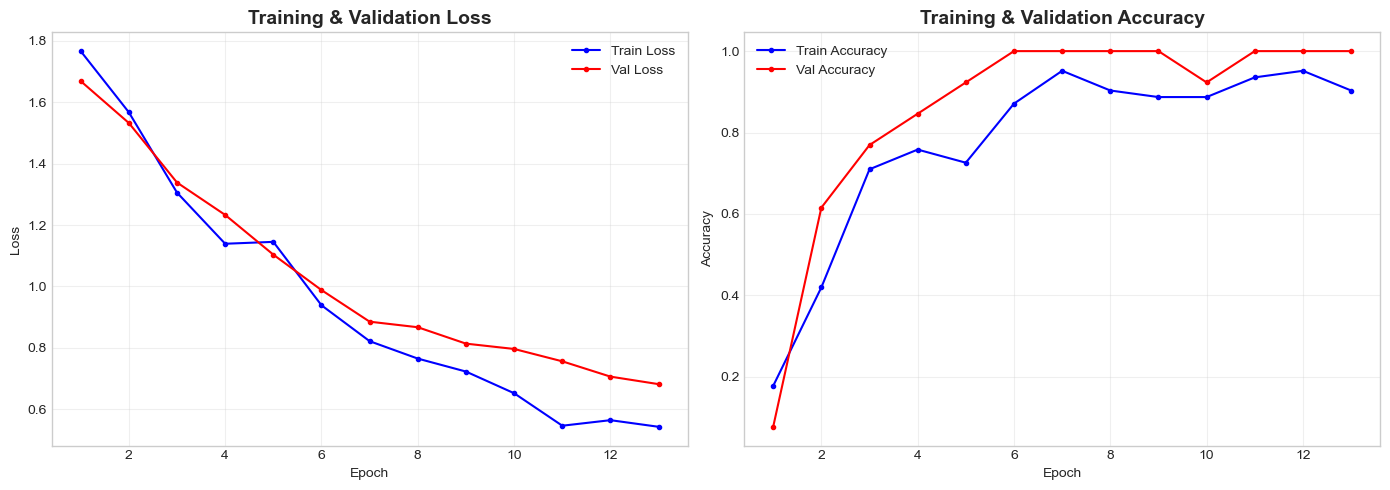

In [6]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=3)
axes[0].plot(epochs_range, history['val_loss'], 'r-o', label='Val Loss', markersize=3)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Accuracy', markersize=3)
axes[1].plot(epochs_range, history['val_acc'], 'r-o', label='Val Accuracy', markersize=3)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'image_training_curves.png'), dpi=150)
plt.show()

## 5. Test Set Evaluation

In [7]:
# Load best model
model.load_state_dict(torch.load(os.path.join(MODEL_DIR, 'image_classifier.pth'), 
                                  map_location=device, weights_only=True))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Classification report
print('Test Set Classification Report:\n')
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

test_acc = (all_preds == all_labels).mean()
print(f'Overall Test Accuracy: {test_acc:.4f}')

Test Set Classification Report:

                precision    recall  f1-score   support

    electrical       0.75      1.00      0.86         3
general_repair       1.00      1.00      1.00         1
          hvac       1.00      1.00      1.00         3
      painting       1.00      0.50      0.67         4
      plumbing       0.50      1.00      0.67         1
       roofing       1.00      1.00      1.00         3

      accuracy                           0.87        15
     macro avg       0.88      0.92      0.87        15
  weighted avg       0.92      0.87      0.86        15

Overall Test Accuracy: 0.8667


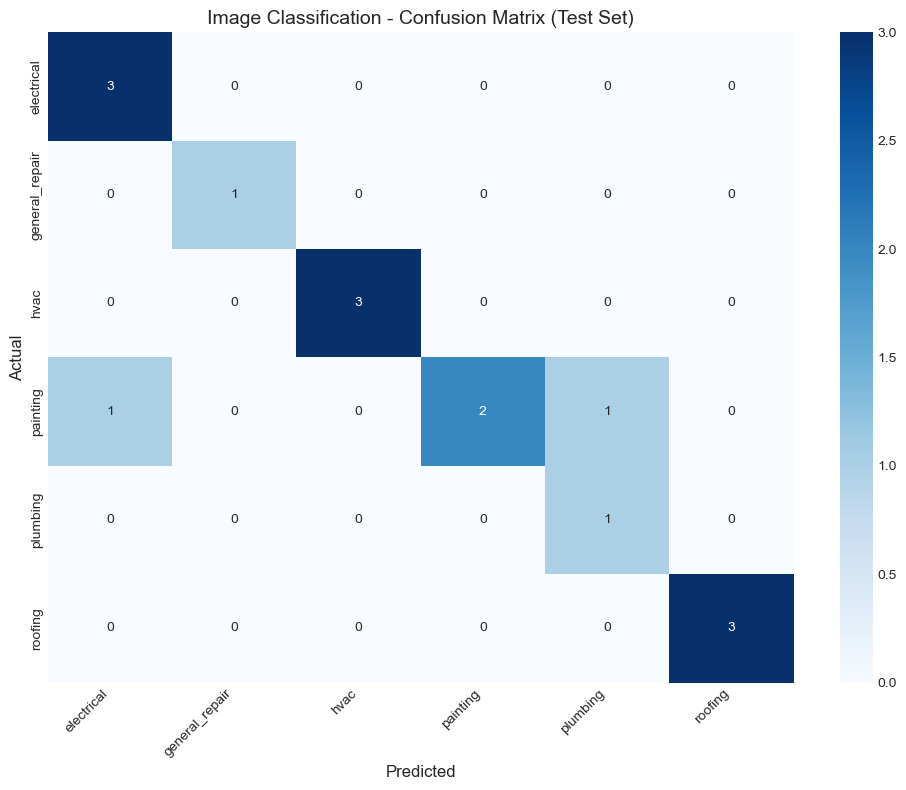

In [8]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Image Classification - Confusion Matrix (Test Set)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'image_confusion_matrix.png'), dpi=150)
plt.show()

## 6. Sample Predictions

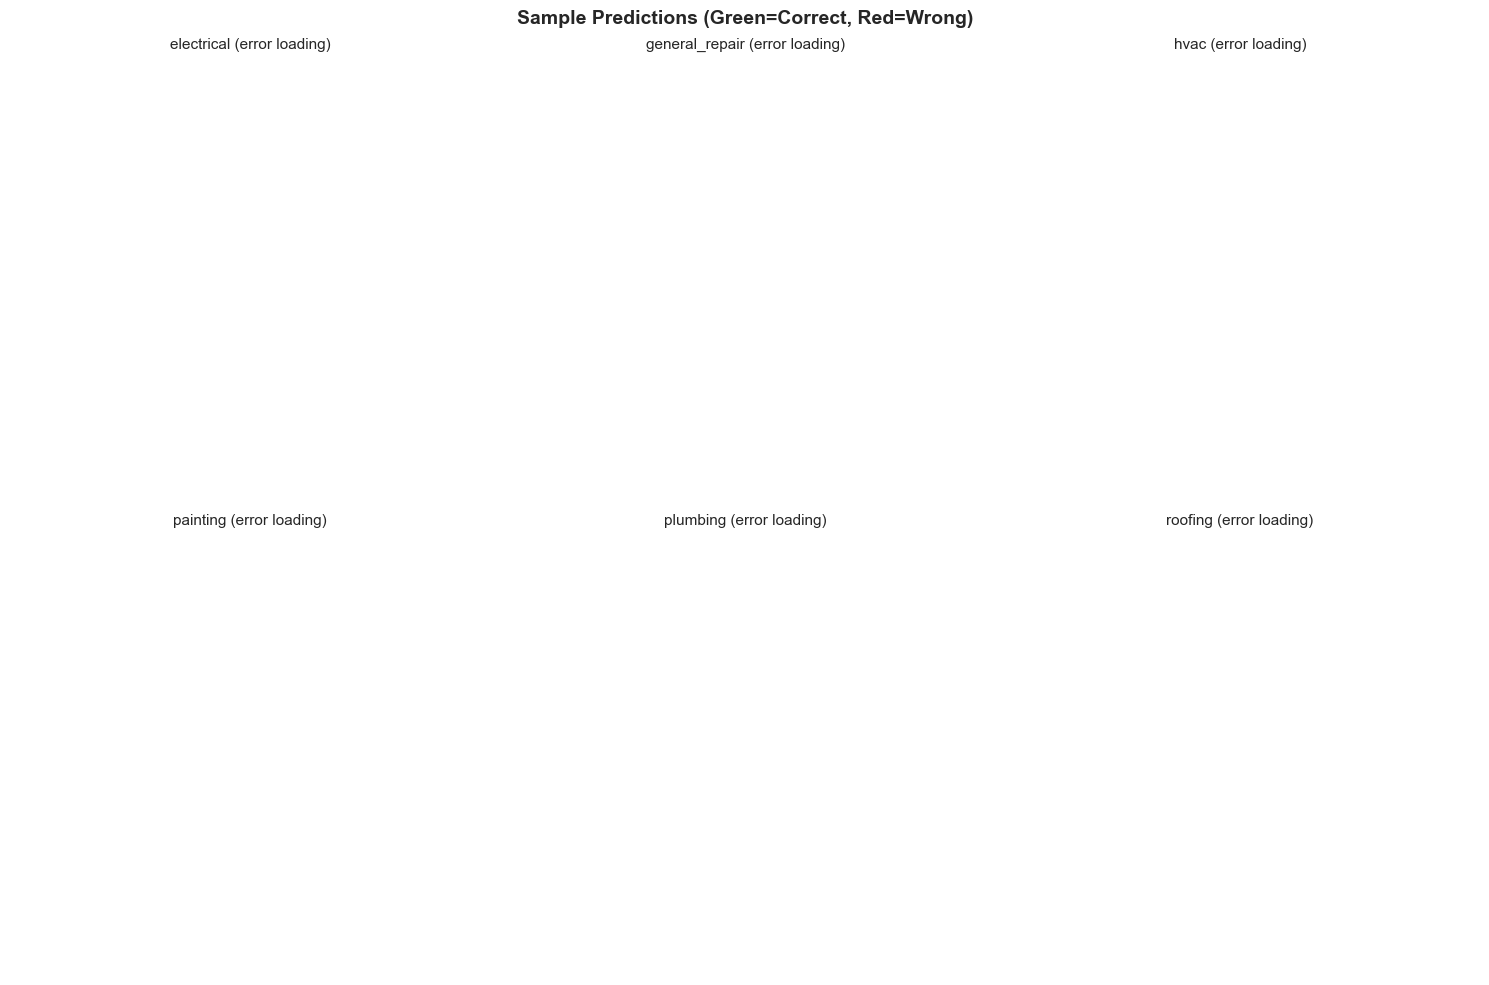

In [9]:
# Show sample predictions
from src.cv_pipeline import predict_image, load_model

test_model = load_model()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, (cat, ax) in enumerate(zip(class_names, axes.flat)):
    cat_dir = os.path.join(IMAGE_DIR, cat)
    imgs = [f for f in os.listdir(cat_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        img_path = os.path.join(cat_dir, imgs[0])
        try:
            result = predict_image(test_model, img_path)
            img = Image.open(img_path).convert('RGB').resize((224, 224))
            ax.imshow(img)
            pred = result['category'].replace('_', ' ').title()
            conf = result['confidence']
            correct = result['category'] == cat
            color = 'green' if correct else 'red'
            ax.set_title(f'True: {cat}\nPred: {pred} ({conf:.1%})', 
                        color=color, fontsize=11, fontweight='bold')
        except:
            ax.set_title(f'{cat} (error loading)', fontsize=11)
    ax.axis('off')

from PIL import Image
plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'image_sample_predictions.png'), dpi=150)
plt.show()

## Summary

We trained a MobileNetV2-based image classifier using transfer learning:

- **Architecture**: MobileNetV2 pretrained backbone (frozen) + custom classifier head
- **Training**: Only 7,686 trainable parameters (0.2% of total) — the rest are frozen
- **Augmentation**: Aggressive augmentation to compensate for small dataset size
- **Optimization**: Adam optimizer with learning rate scheduling and early stopping

### Key Observations
- Transfer learning enables effective training even with a small dataset
- The frozen backbone provides powerful feature representations from ImageNet pretraining
- Data augmentation helps prevent overfitting on the small training set
- The model learns to distinguish between visually different job categories